COMP 293F Final Project

Authors: Prabhleen Gill, Sophie Tran

This project is a repeated-game cybersecurity simulation developed in Python to model interactions between phishing attackers and defenders.

In [ ]:
import random

#random.seed(1)

# Strategies
defender_strategies = ["NS", "LS", "HS"]
attacker_strategies = ["N", "B", "S"]

# Defender security cost
security_cost = {
    "NS": 0,
    "LS": 2,
    "HS": 5
}

# Attacker cost
attack_cost = {
    "N": 0,
    "B": 0.5,
    "S": 1.5
}

# Base probability factors
delivery = {
    ("NS", "B"): 0.8, ("NS", "S"): 0.9,
    ("LS", "B"): 0.6, ("LS", "S"): 0.75,
    ("HS", "B"): 0.3, ("HS", "S"): 0.5
}

click = {
    ("NS", "B"): 0.5, ("NS", "S"): 0.7,
    ("LS", "B"): 0.3, ("LS", "S"): 0.5,
    ("HS", "B"): 0.1, ("HS", "S"): 0.2
}

credential = {
    ("NS", "B"): 0.7, ("NS", "S"): 0.85,
    ("LS", "B"): 0.5, ("LS", "S"): 0.65,
    ("HS", "B"): 0.2, ("HS", "S"): 0.35
}

monetize = {
    ("NS", "B"): 0.8, ("NS", "S"): 0.9,
    ("LS", "B"): 0.7, ("LS", "S"): 0.8,
    ("HS", "B"): 0.5, ("HS", "S"): 0.6
}

# Loss values if attack succeeds
fraud_loss = {
    "B": 5,
    "S": 12
}

response_cost = {
    "NS": 3,
    "LS": 2,
    "HS": 1
}

downtime_loss = {
    ("NS", "B"): 2, ("NS", "S"): 4,
    ("LS", "B"): 1.5, ("LS", "S"): 3,
    ("HS", "B"): 1, ("HS", "S"): 2
}

reputation_loss = {
    "B": 1,
    "S": 3
}

# Attacker gets part of defender loss
gain_multiplier = {
    "B": 0.7,
    "S": 0.9
}

# Detection and penalties
p_caught = {
    ("NS", "B"): 0.05, ("NS", "S"): 0.08,
    ("LS", "B"): 0.15, ("LS", "S"): 0.20,
    ("HS", "B"): 0.35, ("HS", "S"): 0.45
}

penalty = {
    "B": 1.5,
    "S": 3
}


def compute_adjusted_click(defender, attacker, awareness):
    """
    Awareness reduces click probability.
    Higher awareness means users are less likely to click.
    """
    base_click = click[(defender, attacker)]

    adjusted_click = base_click - 0.05 * awareness

    if adjusted_click < 0.05:
        adjusted_click = 0.05

    return adjusted_click


def compute_p_success(defender, attacker, awareness):
    if attacker == "N":
        return 0

    adjusted_click = compute_adjusted_click(defender, attacker, awareness)

    return (delivery[(defender, attacker)] *
            adjusted_click *
            credential[(defender, attacker)] *
            monetize[(defender, attacker)])


def compute_loss(defender, attacker):
    if attacker == "N":
        return 0

    return (fraud_loss[attacker] +
            response_cost[defender] +
            downtime_loss[(defender, attacker)] +
            reputation_loss[attacker])


def compute_gain(defender, attacker):
    if attacker == "N":
        return 0

    loss = compute_loss(defender, attacker)
    return gain_multiplier[attacker] * loss


def compute_utilities(defender, attacker, awareness):
    p_success = compute_p_success(defender, attacker, awareness)
    loss = compute_loss(defender, attacker)
    gain = compute_gain(defender, attacker)

    defender_utility = -security_cost[defender] - (p_success * loss)

    if attacker == "N":
        attacker_utility = 0
    else:
        attacker_utility = (p_success * gain
                            - attack_cost[attacker]
                            - p_caught[(defender, attacker)] * penalty[attacker])

    return p_success, loss, gain, defender_utility, attacker_utility


def choose_defender_strategy(history, successful_attacks):
    # After 2 successful attacks total, stay at HS permanently
    if successful_attacks >= 2:
        return "HS"

    # Start at NS
    if len(history) == 0:
        return "NS"

    last_round = history[-1]

    # If last round had a successful attack, move to HS
    if last_round["success"] and last_round["attacker"] != "N":
        return "HS"

    # If there was an attack attempt last round, move to LS
    if last_round["attacker"] in ["B", "S"]:
        return "LS"

    # Otherwise keep same strategy
    return last_round["defender"]


def choose_attacker_strategy(history, defender, negative_attack_count):
    # After 3 negative attack payoffs, attacker gives up permanently
    if negative_attack_count >= 3:
        return "N"

    if len(history) == 0:
        return "B"

    last_round = history[-1]

    # If defender is at HS, attacker stops
    if defender == "HS":
        return "N"

    # If last attack had positive payoff, keep using it
    if last_round["attacker"] in ["B", "S"] and last_round["attacker_utility"] > 0:
        return last_round["attacker"]

    # If B was bad, try S
    if last_round["attacker"] == "B":
        return "S"

    # If S was bad, stop
    if last_round["attacker"] == "S":
        return "N"

    return "B"


def update_awareness(history, current_awareness):
    """
    Awareness goes up after any phishing attempt.
    Awareness goes down after 2 no-attack rounds in a row.
    """
    if len(history) == 0:
        return current_awareness

    last_round = history[-1]

    # Increase awareness after phishing attempt
    if last_round["attacker"] in ["B", "S"]:
        current_awareness += 1

    # Decrease awareness after 2 no-attack rounds
    if len(history) >= 2:
        if history[-1]["attacker"] == "N" and history[-2]["attacker"] == "N":
            current_awareness -= 1

    # Keep awareness between 0 and 5
    if current_awareness < 0:
        current_awareness = 0
    if current_awareness > 5:
        current_awareness = 5

    return current_awareness


def run_game(rounds):
    history = []
    successful_attacks = 0
    negative_attack_count = 0
    awareness = 0

    for i in range(1, rounds + 1):
        defender = choose_defender_strategy(history, successful_attacks)
        attacker = choose_attacker_strategy(history, defender, negative_attack_count)

        p_success, loss, gain, d_util, a_util = compute_utilities(defender, attacker, awareness)

        if attacker == "N":
            success = False
        else:
            success = random.random() < p_success

        if attacker != "N":
            if success:
                successful_attacks += 1

            if a_util < 0:
                negative_attack_count += 1
            else:
                negative_attack_count = 0

        round_data = {
            "round": i,
            "defender": defender,
            "attacker": attacker,
            "awareness": awareness,
            "p_success": p_success,
            "loss": loss,
            "gain": gain,
            "defender_utility": d_util,
            "attacker_utility": a_util,
            "success": success,
            "successful_attacks_so_far": successful_attacks,
            "negative_attack_count": negative_attack_count
        }

        history.append(round_data)

        # Update awareness for future rounds
        awareness = update_awareness(history, awareness)

    return history


def print_results(history):
    print("Round | Defender | Attacker | Awareness | P(success) | Def Utility | Att Utility | Success")
    print("-" * 95)

    total_def = 0
    total_att = 0

    for item in history:
        print(
            item["round"], "    |",
            item["defender"], "      |",
            item["attacker"], "       |",
            item["awareness"], "         |",
            round(item["p_success"], 4), "     |",
            round(item["defender_utility"], 4), "     |",
            round(item["attacker_utility"], 4), "     |",
            item["success"]
        )

        total_def += item["defender_utility"]
        total_att += item["attacker_utility"]

    print("\nTotal Defender Utility:", round(total_def, 4))
    print("Total Attacker Utility:", round(total_att, 4))


history = run_game(20)
print_results(history)

Round | Defender | Attacker | Awareness | P(success) | Def Utility | Att Utility | Success
-----------------------------------------------------------------------------------------------
1     | NS       | B        | 0          | 0.224      | -2.464      | 1.1498      | False
2     | LS       | B        | 1          | 0.0525      | -2.4987      | -0.3759      | False
3     | LS       | S        | 2          | 0.156      | -5.12      | 0.708      | False
4     | LS       | S        | 3          | 0.1365      | -4.73      | 0.357      | False
5     | LS       | S        | 4          | 0.117      | -4.34      | 0.006      | False
6     | LS       | S        | 5          | 0.0975      | -3.95      | -0.345      | False
7     | LS       | N        | 5          | 0      | -2      | 0      | False
8     | LS       | B        | 5          | 0.0105      | -2.0997      | -0.6552      | False
9     | LS       | S        | 5          | 0.0975      | -3.95      | -0.345      | False
10     | LS    

In [ ]:
import matplotlib.pyplot as plt

def plot_awareness_over_time(history):
    rounds = []
    awareness_values = []

    for item in history:
        rounds.append(item["round"])
        awareness_values.append(item["awareness"])

    plt.figure(figsize=(10, 4))
    plt.plot(rounds, awareness_values, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Awareness")
    plt.title("Defender Awareness Over Time")
    plt.grid(True)
    plt.show()


def plot_utilities_over_time(history):
    rounds = []
    defender_utilities = []
    attacker_utilities = []

    for item in history:
        rounds.append(item["round"])
        defender_utilities.append(item["defender_utility"])
        attacker_utilities.append(item["attacker_utility"])

    plt.figure(figsize=(10, 5))
    plt.plot(rounds, defender_utilities, marker='o', label='Defender Utility')
    plt.plot(rounds, attacker_utilities, marker='s', label='Attacker Utility')
    plt.xlabel("Round")
    plt.ylabel("Utility")
    plt.title("Utilities Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_success_probability_over_time(history):
    rounds = []
    p_success_values = []

    for item in history:
        rounds.append(item["round"])
        p_success_values.append(item["p_success"])

    plt.figure(figsize=(10, 4))
    plt.plot(rounds, p_success_values, marker='o')
    plt.xlabel("Round")
    plt.ylabel("P(success)")
    plt.title("Probability of Success Over Time")
    plt.grid(True)
    plt.show()

In [ ]:
def plot_cumulative_total_utility(history):
    rounds = []
    cumulative_defender = []
    cumulative_attacker = []

    total_def = 0
    total_att = 0

    for item in history:
        total_def += item["defender_utility"]
        total_att += item["attacker_utility"]

        rounds.append(item["round"])
        cumulative_defender.append(total_def)
        cumulative_attacker.append(total_att)

    plt.figure(figsize=(10, 5))
    plt.plot(rounds, cumulative_defender, marker='o', label='Cumulative Defender Utility')
    plt.plot(rounds, cumulative_attacker, marker='s', label='Cumulative Attacker Utility')
    plt.xlabel("Round")
    plt.ylabel("Cumulative Utility")
    plt.title("Cumulative Total Utility")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_state_transitions(history):
    # A state is written like LS-B or HS-N
    rounds = []
    state_numbers = []
    state_labels = []

    # Collect unique states in the order they first appear
    for item in history:
        state = item["defender"] + "-" + item["attacker"]
        if state not in state_labels:
            state_labels.append(state)

    # Map each state to a number
    state_map = {}
    for i in range(len(state_labels)):
        state_map[state_labels[i]] = i

    # Build the points for plotting
    for item in history:
        state = item["defender"] + "-" + item["attacker"]
        rounds.append(item["round"])
        state_numbers.append(state_map[state])

    plt.figure(figsize=(10, 5))
    plt.plot(rounds, state_numbers, marker='o')
    plt.xlabel("Round")
    plt.ylabel("State")
    plt.title("State Transition View")
    plt.yticks(range(len(state_labels)), state_labels)
    plt.grid(True)
    plt.show()

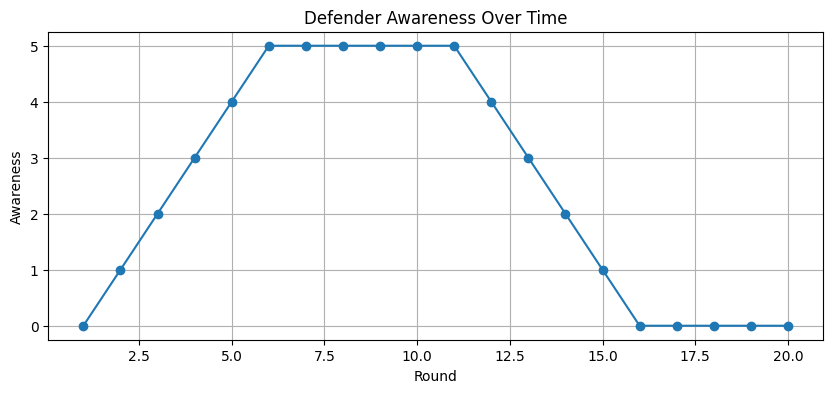

In [ ]:
plot_awareness_over_time(history)

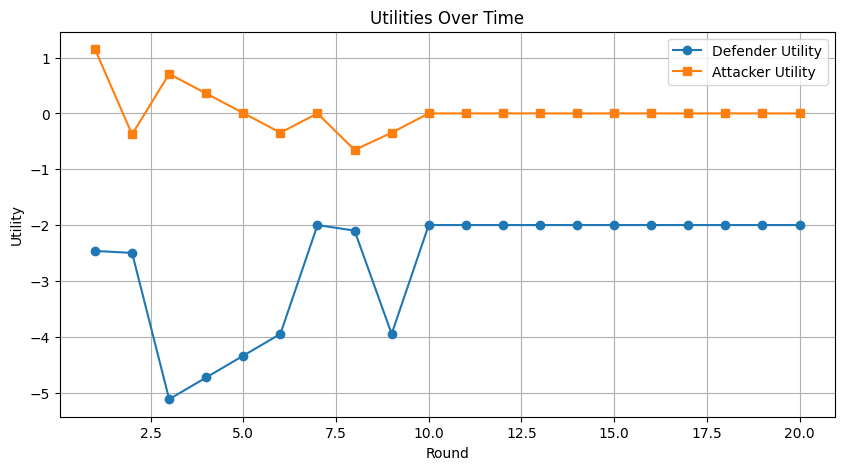

In [ ]:
plot_utilities_over_time(history)

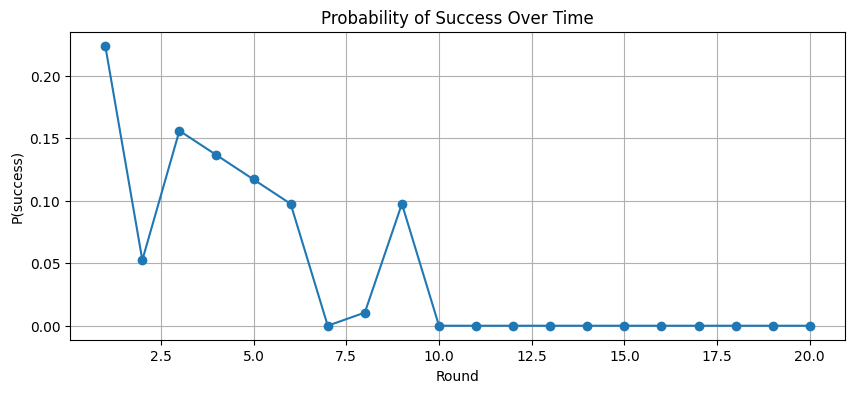

In [ ]:
plot_success_probability_over_time(history)

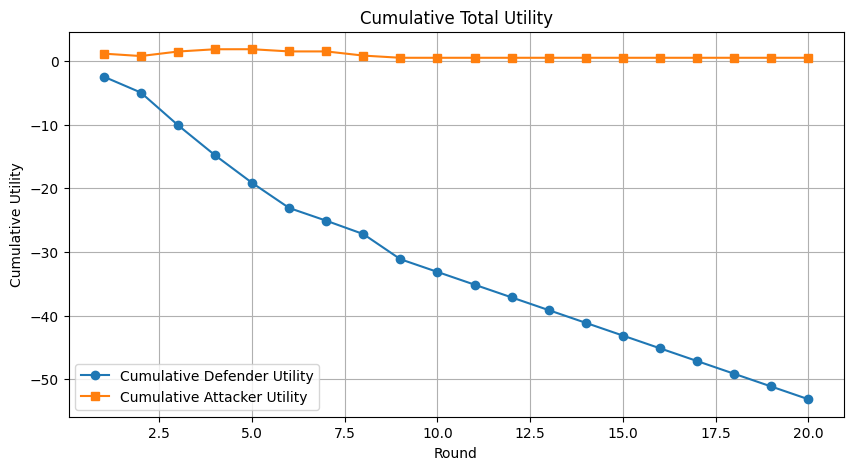

In [ ]:
plot_cumulative_total_utility(history)

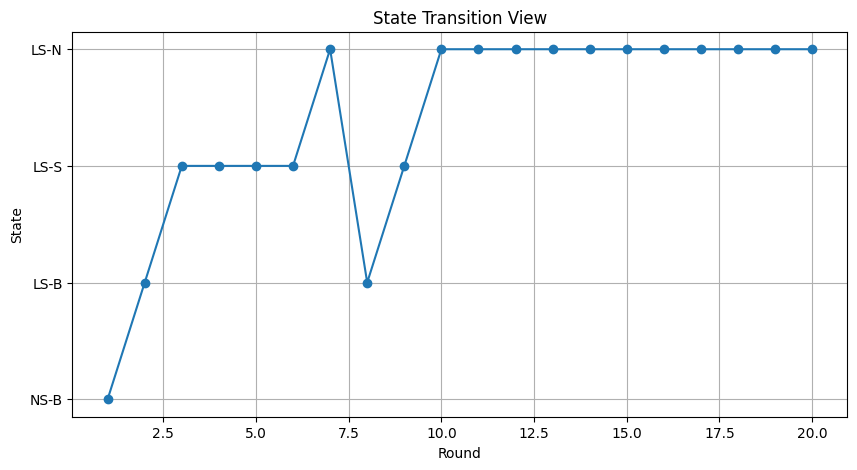

In [ ]:
plot_state_transitions(history)

In [ ]:
def print_matrix(awareness, title):
    defender_strategies = ["NS", "LS", "HS"]
    attacker_strategies = ["N", "B", "S"]

    print(f"\n{title}")
    print(f"Awareness = {awareness}")
    print("Each cell = (Defender Utility, Attacker Utility)\n")

    print("        N                B                S")
    for d in defender_strategies:
        row = f"{d}  "
        for a in attacker_strategies:
            _, _, _, d_util, a_util = compute_utilities(d, a, awareness)
            row += f"{(round(d_util,2), round(a_util,2))}    "
        print(row)

In [ ]:
print_matrix(0, "Initial Payoff Matrix")
print_matrix(5, "Final Payoff Matrix (High Awareness)")


Initial Payoff Matrix
Awareness = 0
Each cell = (Defender Utility, Attacker Utility)

        N                B                S
NS  (0, 0)    (-2.46, 1.15)    (-10.6, 7.8)    
LS  (-2, 0)    (-2.6, -0.31)    (-5.9, 1.41)    
HS  (-5, 0)    (-5.02, -1.01)    (-5.38, -2.51)    

Final Payoff Matrix (High Awareness)
Awareness = 5
Each cell = (Defender Utility, Attacker Utility)

        N                B                S
NS  (0, 0)    (-1.23, 0.29)    (-6.82, 4.39)    
LS  (-2, 0)    (-2.1, -0.66)    (-3.95, -0.34)    
HS  (-5, 0)    (-5.01, -1.02)    (-5.09, -2.76)    
